In [3]:
!pip install pandas
!pip install np

  Preparing metadata (setup.py) ... done
  Created wheel for np: filename=np-1.0.2-py3-none-any.whl size=13657 sha256=75cff47fb4be723c543e6de690443af71d4e21c59f2f028c70d178159dc90cc9
  Stored in directory: /root/.cache/pip/wheels/19/20/42/6ee214e617f78123903f603524d662ac6fa14154c3027fd992
Successfully built np


In [5]:
import requests
import pandas as pd

# ChEMBL base URL
base_url = "https://www.ebi.ac.uk"

# PPAR targets
targets = ['CHEMBL234', 'CHEMBL235', 'CHEMBL236']
all_data = []

for target in targets:
    print(f"Fetching data for {target}...")
    url = f"{base_url}/chembl/api/data/activity.json?target_chembl_id={target}&limit=1000"
    while url:
        res = requests.get(url)
        data = res.json()
        activities = data.get('activities', [])
        for act in activities:
            all_data.append({
                'molecule_chembl_id': act.get('molecule_chembl_id'),
                'target_chembl_id': act.get('target_chembl_id'),
                'standard_type': act.get('standard_type'),
                'standard_value': act.get('standard_value'),
                'standard_units': act.get('standard_units'),
                'canonical_smiles': act.get('canonical_smiles'),
                'pchembl_value': act.get('pchembl_value'),
                'activity_comment': act.get('activity_comment')
            })
        next_url = data.get('page_meta', {}).get('next')
        url = base_url + next_url if next_url else None

df = pd.DataFrame(all_data)

# Filter meaningful data
df = df[df['standard_type'].isin(['IC50', 'EC50', 'Ki', 'Kd', 'Potency'])]
df.dropna(subset=['standard_value', 'canonical_smiles'], inplace=True)

# compute pIC50
df['standard_value'] = df['standard_value'].astype(float)
df['pIC50'] = -df['standard_value'].apply(lambda x: np.log10(x * 1e-9) if x > 0 else None)

# Save to CSV
df.to_csv('ppar_binding_affinity_dataset.csv', index=False)
print("Dataset saved as 'ppar_binding_affinity_dataset.csv'")


Fetching data for CHEMBL234...
Fetching data for CHEMBL235...
Fetching data for CHEMBL236...
✅ Dataset saved as 'ppar_binding_affinity_dataset.csv'


In [6]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.9/34.9 MB 52.3 MB/s eta 0:00:00


In [7]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors

# Load the CSV dataset
df = pd.read_csv("ppar_binding_affinity_dataset.csv")

# Create a list of descriptor names and functions
descriptor_list = [desc[0] for desc in Descriptors._descList]
descriptor_funcs = [desc[1] for desc in Descriptors._descList]

# Calculate descriptors
descriptor_data = []
valid_indices = []

for i, smi in enumerate(df['canonical_smiles']):
    mol = Chem.MolFromSmiles(smi)
    if mol:
        values = [f(mol) for f in descriptor_funcs]
        descriptor_data.append(values)
        valid_indices.append(i)

# Keep only valid rows
descriptor_df = pd.DataFrame(descriptor_data, columns=descriptor_list)
df = df.iloc[valid_indices].reset_index(drop=True)
descriptor_df = descriptor_df.reset_index(drop=True)
df['pIC50'] = df['pIC50'].astype(float)

# Save processed features and labels
descriptor_df.to_csv("ppar_descriptors.csv", index=False)
df[['pIC50']].to_csv("ppar_labels.csv", index=False)

print("Descriptors saved as 'ppar_descriptors.csv'")
print("Labels saved as 'ppar_labels.csv'")

✅ Descriptors saved as 'ppar_descriptors.csv'
✅ Labels saved as 'ppar_labels.csv'


In [9]:
import numpy as np

# Check features
print("NaNs in X:", X.isna().sum().sum())
print("Infs in X:", np.isinf(X).sum().sum())

# Check labels
print("NaNs in y:", np.isnan(y).sum())
print("Infs in y:", np.isinf(y).sum())

NaNs in X: 868
Infs in X: 0
NaNs in y: 2
Infs in y: 0


In [10]:
# Combine and clean
data = X.copy()
data['pIC50'] = y
data.replace([np.inf, -np.inf], np.nan, inplace=True)
data.dropna(inplace=True)

# Separate again
X_clean = data.drop(columns=['pIC50'])
y_clean = data['pIC50'].values

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.callbacks import EarlyStopping

X_train, X_test, y_train, y_test = train_test_split(X_clean, y_clean, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(X_train_scaled, y_train, validation_split=0.1, epochs=100, callbacks=[early_stop], verbose=1)

# Evaluate
predictions = model.predict(X_test_scaled).flatten()
loss, mae = model.evaluate(X_test_scaled, y_test)
r2 = 1 - np.sum((predictions - y_test)**2) / np.sum((y_test - np.mean(y_test))**2)

print(f"Test MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}")


Epoch 1/100
575/575 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 5.1524 - mae: 1.5734 - val_loss: 1.2092 - val_mae: 0.8609
Epoch 2/100
575/575 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.1430 - mae: 0.8220 - val_loss: 1.0483 - val_mae: 0.7950
Epoch 3/100
575/575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 1.0255 - mae: 0.7789 - val_loss: 0.9884 - val_mae: 0.7633
Epoch 4/100
575/575 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.9390 - mae: 0.7346 - val_loss: 0.9959 - val_mae: 0.7578
Epoch 5/100
575/575 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.8402 - mae: 0.6962 - val_loss: 1.0903 - val_mae: 0.8104
Epoch 6/100
575/575 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.7974 - mae: 0.6763 - val_loss: 0.9176 - val_mae: 0.7218
Epoch 7/100
575/575 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.8211 - mae: 0.6814 - val_loss: 0.9131 - val_mae: 0.7211
Epoch 8/100
575/575 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.7387 - mae: 0.6418 - val_loss: 0.9271 - val_mae: 0.7313
Epoch 9/100
575/575 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/

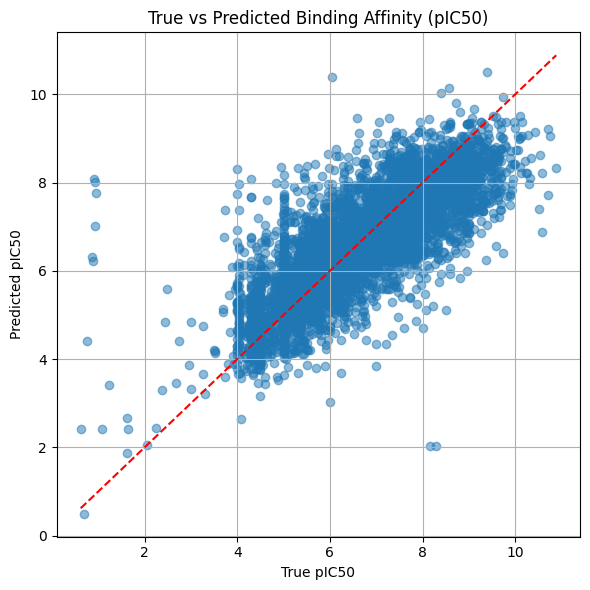

In [13]:
# Plot predictions
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 6))
plt.scatter(y_test, predictions, alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], '--r')
plt.xlabel("True pIC50")
plt.ylabel("Predicted pIC50")
plt.title("True vs Predicted Binding Affinity (pIC50)")
plt.grid(True)
plt.tight_layout()
plt.show()

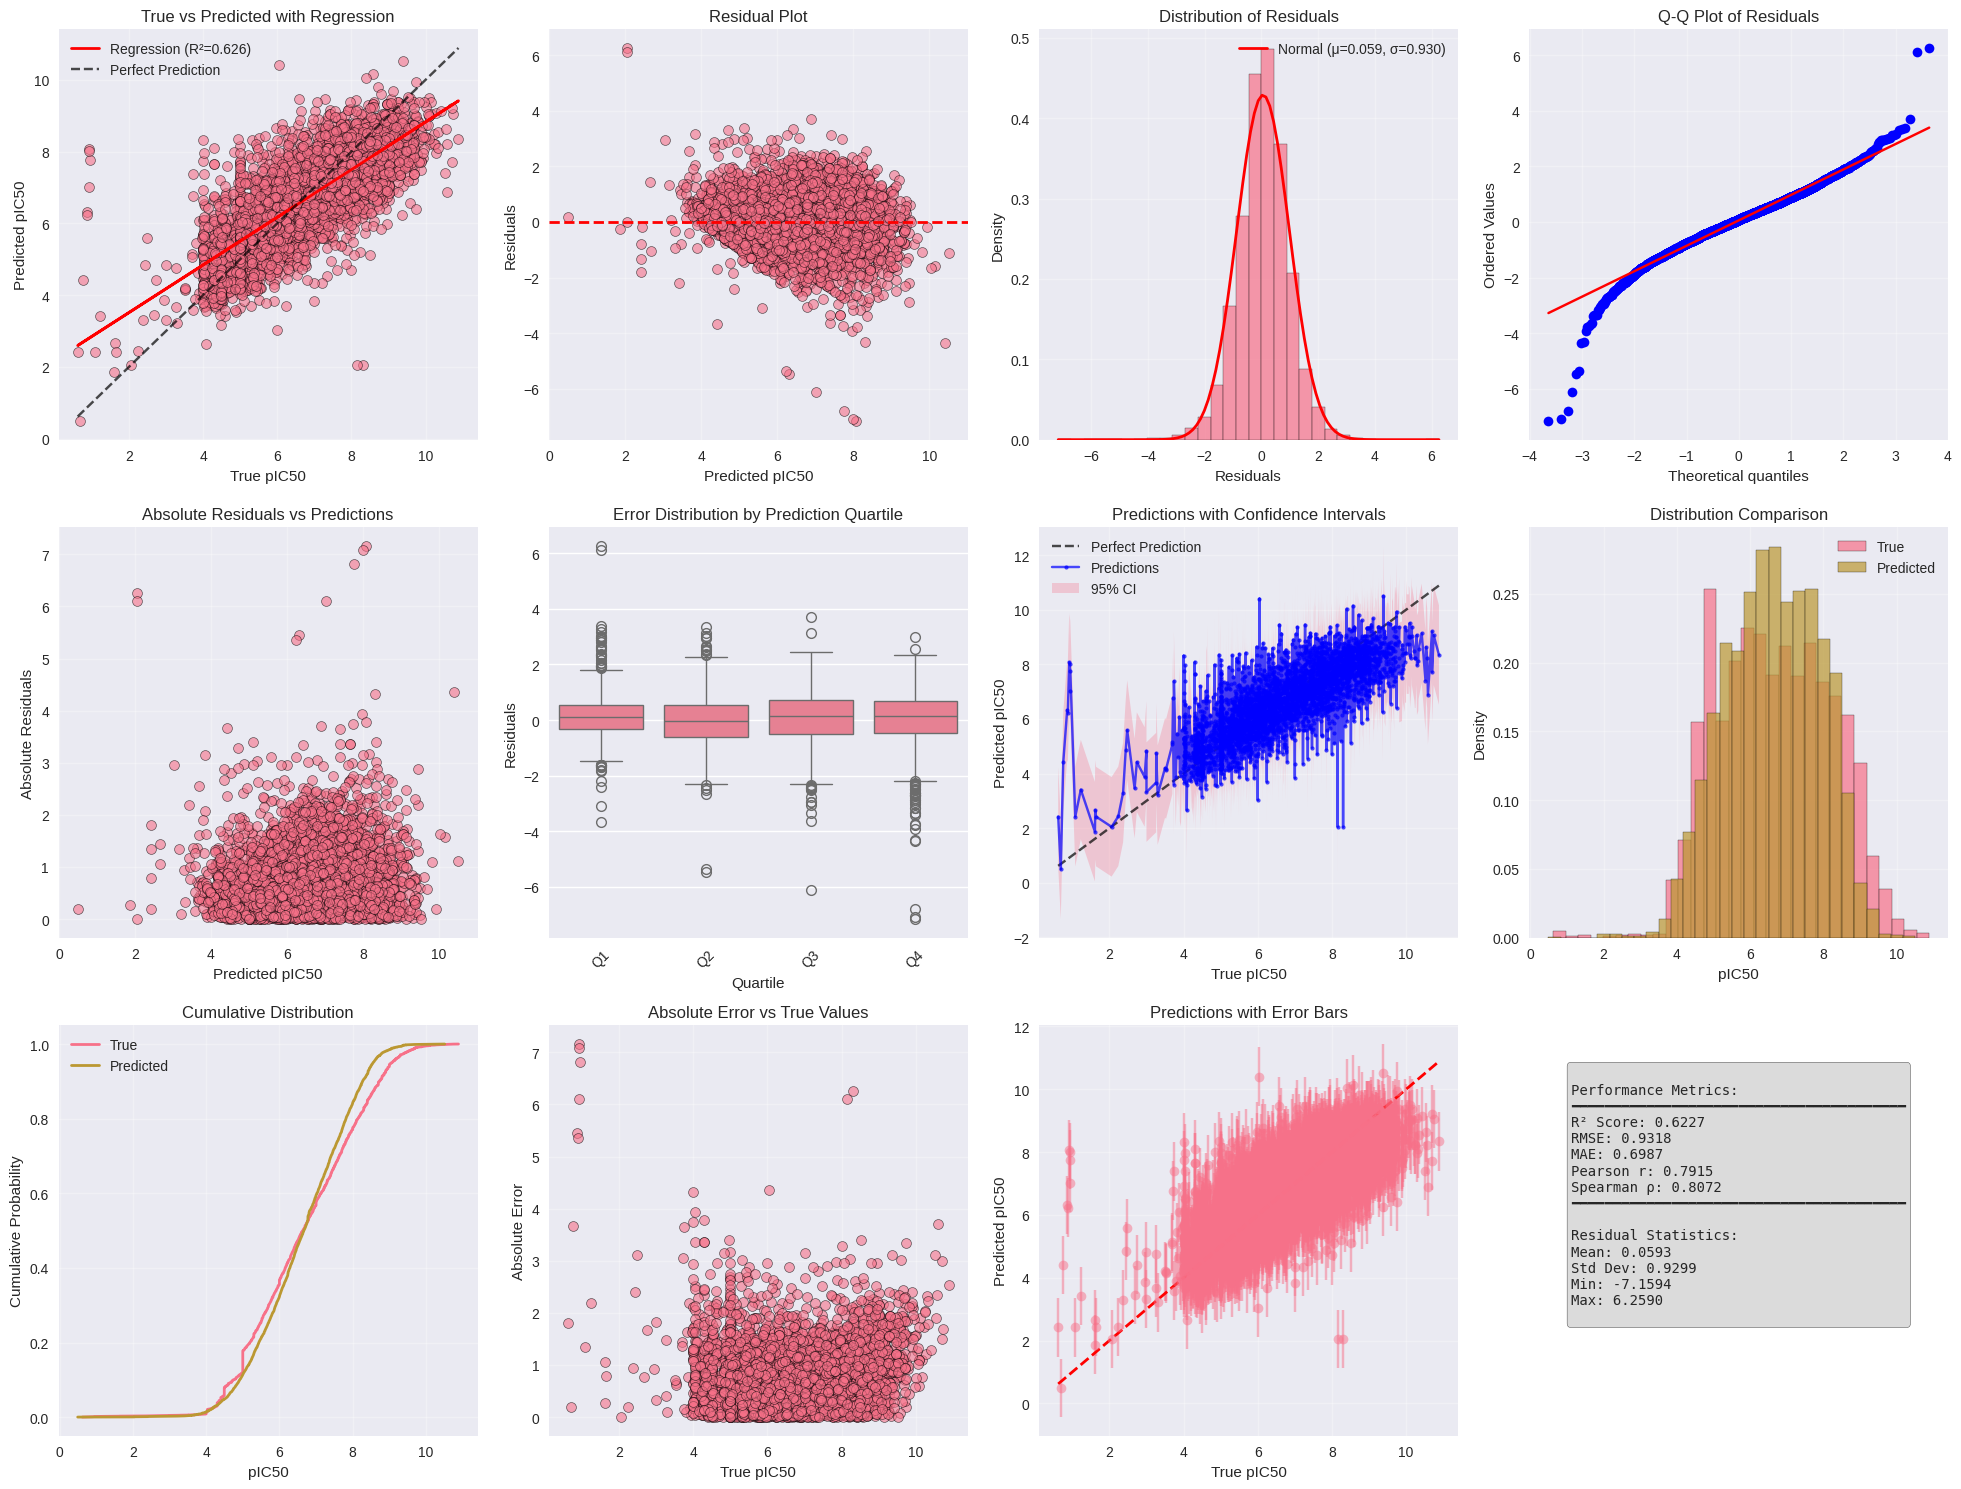

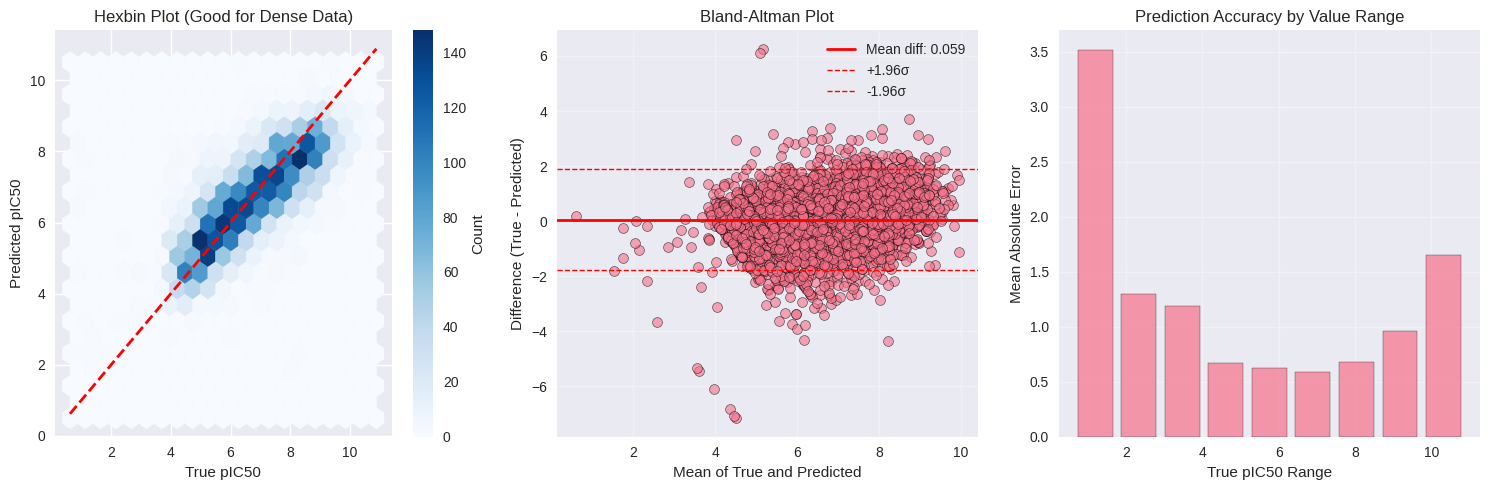

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import pandas as pd

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

fig = plt.figure(figsize=(20, 15))

# 1. Enhanced Scatter Plot with Regression Line
ax1 = plt.subplot(3, 4, 1)
plt.scatter(y_test, predictions, alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
# Add regression line
slope, intercept, r_value, p_value, std_err = stats.linregress(y_test, predictions)
line = slope * y_test + intercept
plt.plot(y_test, line, 'r-', linewidth=2, label=f'Regression (R²={r_value**2:.3f})')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], '--k', alpha=0.7, label='Perfect Prediction')
plt.xlabel("True pIC50")
plt.ylabel("Predicted pIC50")
plt.title("True vs Predicted with Regression")
plt.legend()
plt.grid(True, alpha=0.3)

# 2. Residual Plot
ax2 = plt.subplot(3, 4, 2)
residuals = y_test - predictions
plt.scatter(predictions, residuals, alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel("Predicted pIC50")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.grid(True, alpha=0.3)

# 3. Histogram of Residuals
ax3 = plt.subplot(3, 4, 3)
plt.hist(residuals, bins=30, alpha=0.7, density=True, edgecolor='black')
# Add normal distribution overlay
mu, sigma = stats.norm.fit(residuals)
x = np.linspace(residuals.min(), residuals.max(), 100)
plt.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, label=f'Normal (μ={mu:.3f}, σ={sigma:.3f})')
plt.xlabel("Residuals")
plt.ylabel("Density")
plt.title("Distribution of Residuals")
plt.legend()
plt.grid(True, alpha=0.3)

# 4. Q-Q Plot for Residuals
ax4 = plt.subplot(3, 4, 4)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.grid(True, alpha=0.3)

# 5. Absolute Residuals vs Predictions
ax5 = plt.subplot(3, 4, 5)
abs_residuals = np.abs(residuals)
plt.scatter(predictions, abs_residuals, alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
plt.xlabel("Predicted pIC50")
plt.ylabel("Absolute Residuals")
plt.title("Absolute Residuals vs Predictions")
plt.grid(True, alpha=0.3)

# 6. Error Distribution by Prediction Range
ax6 = plt.subplot(3, 4, 6)
# Bin predictions into quartiles
pred_quartiles = pd.qcut(predictions, q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
residual_df = pd.DataFrame({'Quartile': pred_quartiles, 'Residuals': residuals})
sns.boxplot(data=residual_df, x='Quartile', y='Residuals', ax=ax6)
plt.title("Error Distribution by Prediction Quartile")
plt.xticks(rotation=45)

# 7. Prediction Confidence Intervals (if available)
ax7 = plt.subplot(3, 4, 7)
# Sort data for cleaner plotting
sorted_indices = np.argsort(y_test)
y_test_sorted = y_test[sorted_indices]
predictions_sorted = predictions[sorted_indices]

plt.plot(y_test_sorted, y_test_sorted, 'k--', alpha=0.7, label='Perfect Prediction')
plt.plot(y_test_sorted, predictions_sorted, 'bo-', alpha=0.7, markersize=3, label='Predictions')
plt.fill_between(y_test_sorted,
                 predictions_sorted - 1.96*np.std(residuals),
                 predictions_sorted + 1.96*np.std(residuals),
                 alpha=0.3, label='95% CI')
plt.xlabel("True pIC50")
plt.ylabel("Predicted pIC50")
plt.title("Predictions with Confidence Intervals")
plt.legend()
plt.grid(True, alpha=0.3)

# 8. Density Plot of True vs Predicted
ax8 = plt.subplot(3, 4, 8)
plt.hist(y_test, bins=30, alpha=0.7, label='True', density=True, edgecolor='black')
plt.hist(predictions, bins=30, alpha=0.7, label='Predicted', density=True, edgecolor='black')
plt.xlabel("pIC50")
plt.ylabel("Density")
plt.title("Distribution Comparison")
plt.legend()
plt.grid(True, alpha=0.3)

# 9. Cumulative Distribution Function
ax9 = plt.subplot(3, 4, 9)
sorted_true = np.sort(y_test)
sorted_pred = np.sort(predictions)
y_cdf = np.arange(1, len(sorted_true) + 1) / len(sorted_true)
plt.plot(sorted_true, y_cdf, label='True', linewidth=2)
plt.plot(sorted_pred, y_cdf, label='Predicted', linewidth=2)
plt.xlabel("pIC50")
plt.ylabel("Cumulative Probability")
plt.title("Cumulative Distribution")
plt.legend()
plt.grid(True, alpha=0.3)

# 10. Error vs True Values
ax10 = plt.subplot(3, 4, 10)
plt.scatter(y_test, abs_residuals, alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
plt.xlabel("True pIC50")
plt.ylabel("Absolute Error")
plt.title("Absolute Error vs True Values")
plt.grid(True, alpha=0.3)

# 11. Prediction Intervals
ax11 = plt.subplot(3, 4, 11)
error_std = np.std(residuals)
plt.errorbar(y_test, predictions, yerr=error_std, fmt='o', alpha=0.5, capsize=3)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], '--r', linewidth=2)
plt.xlabel("True pIC50")
plt.ylabel("Predicted pIC50")
plt.title("Predictions with Error Bars")
plt.grid(True, alpha=0.3)

# 12. Performance Metrics Summary
ax12 = plt.subplot(3, 4, 12)
ax12.axis('off')
# Calculate metrics
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)
pearson_r = stats.pearsonr(y_test, predictions)[0]
spearman_r = stats.spearmanr(y_test, predictions)[0]

metrics_text = f"""
Performance Metrics:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
R² Score: {r2:.4f}
RMSE: {rmse:.4f}
MAE: {mae:.4f}
Pearson r: {pearson_r:.4f}
Spearman ρ: {spearman_r:.4f}
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Residual Statistics:
Mean: {np.mean(residuals):.4f}
Std Dev: {np.std(residuals):.4f}
Min: {np.min(residuals):.4f}
Max: {np.max(residuals):.4f}
"""

ax12.text(0.1, 0.9, metrics_text, transform=ax12.transAxes, fontsize=10,
          verticalalignment='top', fontfamily='monospace',
          bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray", alpha=0.8))

plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hexbin(y_test, predictions, gridsize=20, cmap='Blues')
plt.colorbar(label='Count')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], '--r', linewidth=2)
plt.xlabel("True pIC50")
plt.ylabel("Predicted pIC50")
plt.title("Hexbin Plot (Good for Dense Data)")

# 14. Bland-Altman Plot
plt.subplot(1, 3, 2)
mean_values = (y_test + predictions) / 2
diff_values = y_test - predictions
plt.scatter(mean_values, diff_values, alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
plt.axhline(y=np.mean(diff_values), color='red', linestyle='-', linewidth=2, label=f'Mean diff: {np.mean(diff_values):.3f}')
plt.axhline(y=np.mean(diff_values) + 1.96*np.std(diff_values), color='red', linestyle='--', linewidth=1, label='+1.96σ')
plt.axhline(y=np.mean(diff_values) - 1.96*np.std(diff_values), color='red', linestyle='--', linewidth=1, label='-1.96σ')
plt.xlabel("Mean of True and Predicted")
plt.ylabel("Difference (True - Predicted)")
plt.title("Bland-Altman Plot")
plt.legend()
plt.grid(True, alpha=0.3)

# 15. Prediction Accuracy by Value Range
plt.subplot(1, 3, 3)
bins = np.linspace(min(y_test), max(y_test), 10)
bin_centers = (bins[:-1] + bins[1:]) / 2
bin_indices = np.digitize(y_test, bins)
bin_maes = [np.mean(np.abs(y_test[bin_indices == i] - predictions[bin_indices == i]))
           for i in range(1, len(bins)) if np.sum(bin_indices == i) > 0]
valid_centers = [bin_centers[i-1] for i in range(1, len(bins)) if np.sum(bin_indices == i) > 0]

plt.bar(valid_centers, bin_maes, width=(bins[1]-bins[0])*0.8, alpha=0.7, edgecolor='black')
plt.xlabel("True pIC50 Range")
plt.ylabel("Mean Absolute Error")
plt.title("Prediction Accuracy by Value Range")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()